# 03b — Regularización y Selección de Variables: LASSO

**TFM — Valoración Inmobiliaria Masiva: SLX vs Machine Learning**

---

## ¿Qué hace este notebook y por qué existe?

Al final del notebook 03, disponemos de **30 variables**: 18 features originales más 12 retardos espaciales (lags KNN). Sin embargo, introducir las 30 variables directamente en el modelo SLX (una regresión OLS) genera un **problema grave de multicolinealidad**: los retardos espaciales están fuertemente correlacionados entre sí y con las variables originales que les dieron origen (por ejemplo, `sqft_living` y `lag_sqft_living_k15` tienen una correlación de Pearson > 0.7).

Para un modelo OLS, la multicolinealidad:
- Infla los errores estándar de los coeficientes (los hace inestables)
- Dificulta la interpretación económica de los efectos directos vs spillover
- Puede hacer que variables relevantes aparezcan como no significativas

**La solución: regularización LASSO.** El estimador LASSO (_Least Absolute Shrinkage and Selection Operator_) añade una penalización proporcional a la suma de los valores absolutos de los coeficientes (norma L1). Este tipo de penalización tiene una propiedad muy valiosa para la selección de variables: **lleva exactamente a cero los coeficientes de las variables irrelevantes o redundantes**. Esto nos proporciona automáticamente un subconjunto de features que:

1. Minimiza la multicolinealidad antes de ajustar el modelo SLX
2. Identifica qué variables espaciales añaden valor predictivo real más allá de las originales
3. Produce un modelo más parsimonioso e interpretable

**Nota sobre Random Forest y XGBoost:** estos algoritmos **no necesitan** este paso porque los árboles de decisión gestionan la multicolinealidad de forma nativa. El notebook 04 (Random Forest) sigue usando las 23 features directamente desde `X_train_spatial.csv`.

---

## Estructura del notebook

1. **Setup e imports**
2. **Marco teórico** — Función de pérdida LASSO, selección de alpha con cross-validation
3. **Carga de datos** — `X_train_spatial.csv` (23 features)
4. **Estandarización** — Obligatoria para que la penalización L1 sea justa entre variables
5. **LassoCV** — Selección automática del alpha óptimo
6. **Selección de variables** — Identificar features con coeficiente ≠ 0
7. **Visualizaciones** — Path LASSO y coeficientes seleccionados
8. **Construcción de datasets de salida** — Solo las features seleccionadas, en escala original
9. **Guardado** — `X_train_lasso.csv`, `X_test_lasso.csv`, `lasso_selected_features.json`
10. **Conclusiones** — Qué features han sobrevivido y próximos pasos

In [1]:
import sys
import os
sys.path.insert(0, '../src')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import joblib

from sklearn.linear_model import LassoCV, lasso_path
from sklearn.preprocessing import StandardScaler

from utils import set_plot_style, save_metrics

set_plot_style()

PROCESSED = '../data/processed/'
FIGURES   = '../outputs/figures/'
METRICS   = '../outputs/metrics/'
MODELS    = '../outputs/models/'
os.makedirs(FIGURES, exist_ok=True)
os.makedirs(METRICS, exist_ok=True)
os.makedirs(MODELS, exist_ok=True)

RANDOM_STATE = 42

print('Setup completado')
print('Nota: lag_log_price_k15 no se genera en el notebook 03 — simetría metodológica SLX/ML garantizada.')

Setup completado
Nota: lag_log_price_k15 no se genera en el notebook 03 — simetría metodológica SLX/ML garantizada.


## 1. Marco teórico: LASSO y selección de variables

### Función de pérdida LASSO

LASSO minimiza la siguiente función objetivo:

$$\min_{\beta} \left\{ \frac{1}{2n} \|y - X\beta\|_2^2 + \alpha \|\beta\|_1 \right\}$$

donde:
- El primer término es el RSS (error cuadrático residual), igual que en OLS
- El segundo término $\alpha \|\beta\|_1 = \alpha \sum_{j} |\beta_j|$ es la penalización L1
- $\alpha > 0$ es el hiperparámetro que controla la fuerza de la regularización

La penalización L1 (a diferencia de L2/Ridge) genera soluciones **sparse**: para valores suficientemente grandes de $\alpha$, algunos $\beta_j$ se vuelven **exactamente cero**. Esto hace que LASSO actúe simultáneamente como estimador y como selector de variables.

### ¿Por qué es necesario estandarizar?

La penalización LASSO trata todos los coeficientes por igual ($\alpha |\beta_j|$). Si las variables tienen escalas muy distintas (por ejemplo, `sqft_living` ∈ [200, 10.000] vs `waterfront` ∈ [0, 1]), la penalización sería injusta: variables con coeficientes numéricamente pequeños (pero importantes) serían eliminadas antes que variables con escalas grandes. **Estandarizar** (media = 0, std = 1) garantiza que la penalización trata a todas las variables de forma equitativa.

**Importante:** solo el LASSO necesita los datos estandarizados. Los datasets de salida (`X_train_lasso.csv`) se guardan en **escala original**, simplemente con las columnas seleccionadas por LASSO eliminadas.

### Selección de alpha con LassoCV

En lugar de elegir $\alpha$ manualmente, `LassoCV` evalúa automáticamente una rejilla de valores mediante **cross-validation de 5 folds** y selecciona el $\alpha$ que minimiza el error de predicción fuera de muestra. Esto garantiza que el nivel de regularización elegido generaliza bien.

In [2]:
# Cargar los datasets con las 30 features espaciales (output del notebook 03)
X_train = pd.read_csv(PROCESSED + 'X_train_spatial.csv')
X_test  = pd.read_csv(PROCESSED + 'X_test_spatial.csv')
y_train = pd.read_csv(PROCESSED + 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED + 'y_test.csv').squeeze()

print('Dimensiones de los datos cargados:')
print(f'  X_train: {X_train.shape}  (esperado: 17289 x 30)')
print(f'  X_test:  {X_test.shape}  (esperado: 4323 x 30)')
print(f'  y_train: {y_train.shape}')
print(f'  y_test:  {y_test.shape}')
print(f'\nFeatures disponibles ({X_train.shape[1]}):')
for i, col in enumerate(X_train.columns):
    marker = '  ← lag espacial' if col.startswith('lag_') else ''
    print(f'  {i+1:2d}. {col}{marker}')

Dimensiones de los datos cargados:
  X_train: (17289, 30)  (esperado: 17289 x 30)
  X_test:  (4323, 30)  (esperado: 4323 x 30)
  y_train: (17289,)
  y_test:  (4323,)

Features disponibles (30):
   1. bedrooms
   2. bathrooms
   3. sqft_living
   4. sqft_lot
   5. floors
   6. waterfront
   7. view
   8. condition
   9. grade
  10. sqft_above
  11. zipcode
  12. lat
  13. long
  14. sqft_living15
  15. sqft_lot15
  16. sale_month
  17. house_age
  18. renovated
  19. lag_bedrooms_k15  ← lag espacial
  20. lag_bathrooms_k15  ← lag espacial
  21. lag_sqft_living_k15  ← lag espacial
  22. lag_sqft_lot_k15  ← lag espacial
  23. lag_floors_k15  ← lag espacial
  24. lag_waterfront_k15  ← lag espacial
  25. lag_view_k15  ← lag espacial
  26. lag_condition_k15  ← lag espacial
  27. lag_grade_k15  ← lag espacial
  28. lag_sqft_above_k15  ← lag espacial
  29. lag_house_age_k15  ← lag espacial
  30. lag_renovated_k15  ← lag espacial


In [3]:
# Correlaciones entre features originales y sus lags espaciales equivalentes
lag_features = [c for c in X_train.columns if c.startswith('lag_')]
orig_map = {f'lag_{f}_k15': f for f in [
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
    'waterfront', 'view', 'condition', 'grade', 'sqft_above',
    'house_age', 'renovated'
]}

print('Correlaciones entre features originales y sus lags espaciales:')
print(f'{"Feature original":<20} {"Lag espacial":<28} {"Correlación de Pearson":>22}')
print('-' * 73)
for lag, orig in orig_map.items():
    if lag in X_train.columns and orig in X_train.columns:
        r = X_train[orig].corr(X_train[lag])
        print(f'{orig:<20} {lag:<28} {r:>22.4f}')

print('\n→ Multicolinealidad variable según el lag. LASSO seleccionará los más relevantes para SLX.')


Correlaciones entre features originales y sus lags espaciales:
Feature original     Lag espacial                 Correlación de Pearson
-------------------------------------------------------------------------
bedrooms             lag_bedrooms_k15                             0.3342
bathrooms            lag_bathrooms_k15                            0.4684
sqft_living          lag_sqft_living_k15                          0.5841
sqft_lot             lag_sqft_lot_k15                             0.5538
floors               lag_floors_k15                               0.5270
waterfront           lag_waterfront_k15                           0.3709
view                 lag_view_k15                                 0.6010
condition            lag_condition_k15                            0.3299
grade                lag_grade_k15                                0.6519
sqft_above           lag_sqft_above_k15                           0.6179
house_age            lag_house_age_k15                      

## 2. Estandarización de las features

Ajustamos el `StandardScaler` **únicamente sobre el conjunto de train** y lo aplicamos a ambos conjuntos. El scaler se guarda para poder reproducir la transformación en el modelo SLX si fuera necesario.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Verificar que la estandarización es correcta
means = X_train_scaled.mean(axis=0)
stds  = X_train_scaled.std(axis=0)
assert np.allclose(means, 0, atol=1e-10), 'ERROR: medias no son 0'
assert np.allclose(stds,  1, atol=1e-10), 'ERROR: stds no son 1'

# Guardar el scaler para reproducibilidad
joblib.dump(scaler, MODELS + 'lasso_scaler.joblib')
print(f'Scaler ajustado y guardado en: outputs/models/lasso_scaler.joblib')
print(f'X_train_scaled: {X_train_scaled.shape}  (media≈0, std≈1 en todas las columnas)')
print(f'X_test_scaled:  {X_test_scaled.shape}')

Scaler ajustado y guardado en: outputs/models/lasso_scaler.joblib
X_train_scaled: (17289, 30)  (media≈0, std≈1 en todas las columnas)
X_test_scaled:  (4323, 30)


## 3. Ajuste de LassoCV y selección de alpha con regla 1SE

`LassoCV` evalúa una rejilla logarítmica de valores de $\alpha$ mediante 5-fold cross-validation.
Usamos la **regla del 1 error estándar (1SE)** en lugar del alpha que minimiza el error:

- **Alpha mínimo (min-CV):** el que da el menor RMSE medio de validación. Con 30 features y datos con baja
  multicolinealidad, este alpha suele ser muy pequeño y no elimina ninguna variable — inútil para OLS/SLX.
- **Alpha 1SE:** el alpha más grande (más regularizador) cuyo RMSE medio está dentro de 1 desviación estándar
  del mínimo. Produce un modelo más parsimonioso con rendimiento estadísticamente equivalente.

El alpha 1SE es el estándar en econometría cuando el objetivo es selección de variables, no maximizar R².


In [5]:
lasso_cv = LassoCV(
    cv=5,
    max_iter=20000,
    random_state=RANDOM_STATE,
    n_alphas=200,
    n_jobs=-1
)
lasso_cv.fit(X_train_scaled, y_train)

# Alpha mínimo (referencia)
alpha_min = lasso_cv.alpha_

# Regla 1SE: mayor alpha cuyo RMSE medio está dentro de 1 std del mínimo
# lasso_cv.alphas_ está en orden DECRECIENTE (mayor→menor regularización)
# lasso_cv.mse_path_ tiene shape (n_alphas, n_folds)
mse_path_mean = lasso_cv.mse_path_.mean(axis=1)
mse_path_std  = lasso_cv.mse_path_.std(axis=1)

min_idx   = np.argmin(mse_path_mean)
threshold = mse_path_mean[min_idx] + mse_path_std[min_idx]

# Candidatos: todos los alphas cuyo MSE medio ≤ umbral
candidates = np.where(mse_path_mean <= threshold)[0]
# Tomamos el de índice más pequeño = alpha más GRANDE (más conservador)
alpha_1se_idx = candidates[0]
alpha_1se     = lasso_cv.alphas_[alpha_1se_idx]

# Reajustar LASSO con alpha_1se para obtener coeficientes
from sklearn.linear_model import Lasso
lasso_1se = Lasso(alpha=alpha_1se, max_iter=20000)
lasso_1se.fit(X_train_scaled, y_train)

# Usamos alpha_1se como alpha operativo
alpha_opt = alpha_1se
coef_opt  = lasso_1se.coef_
n_nonzero = np.sum(coef_opt != 0)
n_total   = len(coef_opt)

print(f'Alpha mínimo CV (referencia):  α = {alpha_min:.6f}  →  {np.sum(lasso_cv.coef_ != 0)} features')
print(f'Alpha 1SE  (seleccionado):     α = {alpha_1se:.6f}  →  {n_nonzero} features')
print(f'Features seleccionadas (coef ≠ 0): {n_nonzero} de {n_total}')
print(f'Features eliminadas    (coef = 0): {n_total - n_nonzero}')
print(f'\nR² en train (LASSO 1SE, estandarizado): {lasso_1se.score(X_train_scaled, y_train):.4f}')
print(f'R² en train (LASSO min-CV):              {lasso_cv.score(X_train_scaled, y_train):.4f}')


Alpha mínimo CV (referencia):  α = 0.000368  →  30 features
Alpha 1SE  (seleccionado):     α = 0.005918  →  23 features
Features seleccionadas (coef ≠ 0): 23 de 30
Features eliminadas    (coef = 0): 7

R² en train (LASSO 1SE, estandarizado): 0.8208
R² en train (LASSO min-CV):              0.8271


In [6]:
# Tabla de coeficientes LASSO (alpha 1SE) ordenada por valor absoluto
feature_names = X_train.columns.tolist()
coef_df = pd.DataFrame({
    'Feature':        feature_names,
    'Coeficiente':    coef_opt,
    '|Coeficiente|':  np.abs(coef_opt),
    'Seleccionada':   coef_opt != 0,
    'Tipo':           ['Lag espacial' if f.startswith('lag_') else 'Original' for f in feature_names]
}).sort_values('|Coeficiente|', ascending=False)

print(f'Coeficientes LASSO 1SE (α = {alpha_opt:.6f}) ordenados por importancia:')
print(f'{"Feature":<28} {"Tipo":<15} {"Coeficiente":>14} {"Seleccionada":>14}')
print('-' * 75)
for _, row in coef_df.iterrows():
    sel = '✓' if row['Seleccionada'] else '✗'
    print(f'{row["Feature"]:<28} {row["Tipo"]:<15} {row["Coeficiente"]:>14.6f} {sel:>14}')


Coeficientes LASSO 1SE (α = 0.005918) ordenados por importancia:
Feature                      Tipo               Coeficiente   Seleccionada
---------------------------------------------------------------------------
lat                          Original              0.163674              ✓
sqft_living                  Original              0.142843              ✓
lag_house_age_k15            Lag espacial          0.125238              ✓
grade                        Original              0.114020              ✓
lag_grade_k15                Lag espacial          0.084497              ✓
lag_bathrooms_k15            Lag espacial          0.061800              ✓
lag_floors_k15               Lag espacial          0.044420              ✓
condition                    Original              0.033636              ✓
waterfront                   Original              0.031648              ✓
view                         Original              0.030478              ✓
bathrooms                    Origi

## 4. Visualizaciones

### Figura 1: Curva de error CV vs alpha
Muestra cómo varía el error de validación cruzada al cambiar el nivel de regularización. El punto mínimo indica el alpha óptimo.

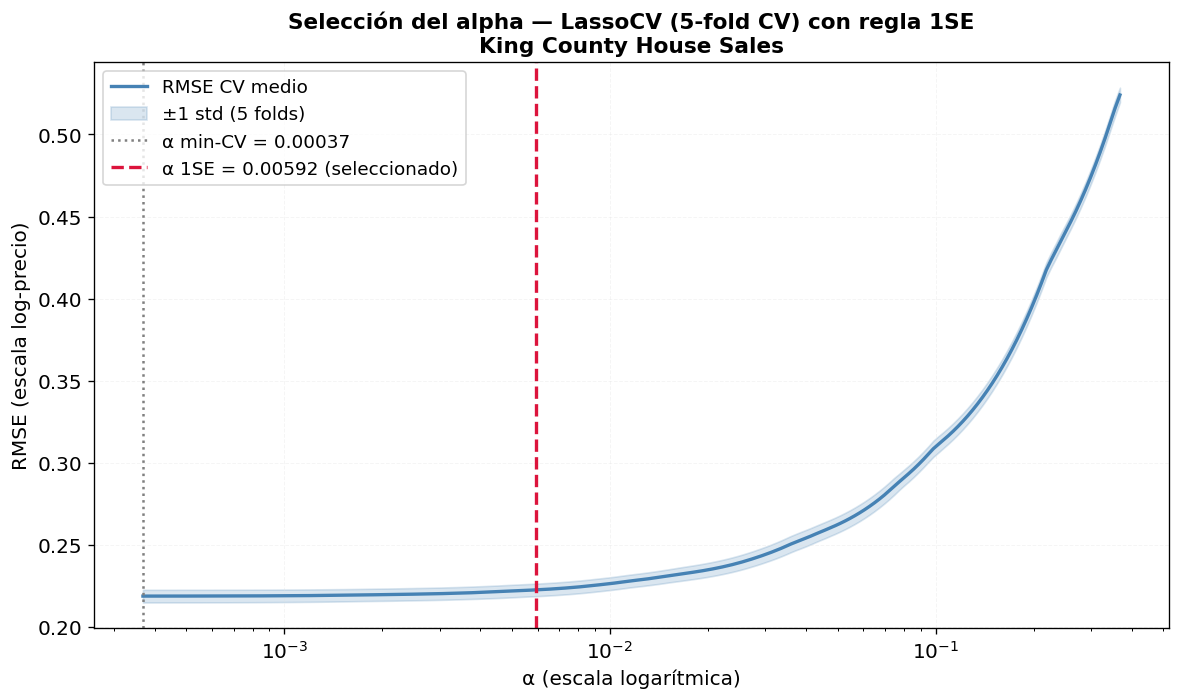

Alpha min-CV: 0.000368  |  Alpha 1SE: 0.005918


In [7]:
# Figura 1: Curva RMSE de CV vs alpha — muestra ambos alphas (min y 1SE)
alphas = lasso_cv.alphas_

fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogx(alphas, np.sqrt(mse_path_mean), color='steelblue', linewidth=2, label='RMSE CV medio')
ax.fill_between(
    alphas,
    np.sqrt(mse_path_mean - mse_path_std),
    np.sqrt(mse_path_mean + mse_path_std),
    alpha=0.2, color='steelblue', label='±1 std (5 folds)'
)
ax.axvline(alpha_min, color='gray',   linestyle=':',  linewidth=1.5, label=f'α min-CV = {alpha_min:.5f}')
ax.axvline(alpha_1se, color='crimson', linestyle='--', linewidth=2.0, label=f'α 1SE = {alpha_1se:.5f} (seleccionado)')

ax.set_xlabel('α (escala logarítmica)', fontsize=12)
ax.set_ylabel('RMSE (escala log-precio)', fontsize=12)
ax.set_title('Selección del alpha — LassoCV (5-fold CV) con regla 1SE\nKing County House Sales',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES + '03b_lasso_cv_alpha.png')
plt.show()
print(f'Alpha min-CV: {alpha_min:.6f}  |  Alpha 1SE: {alpha_1se:.6f}')


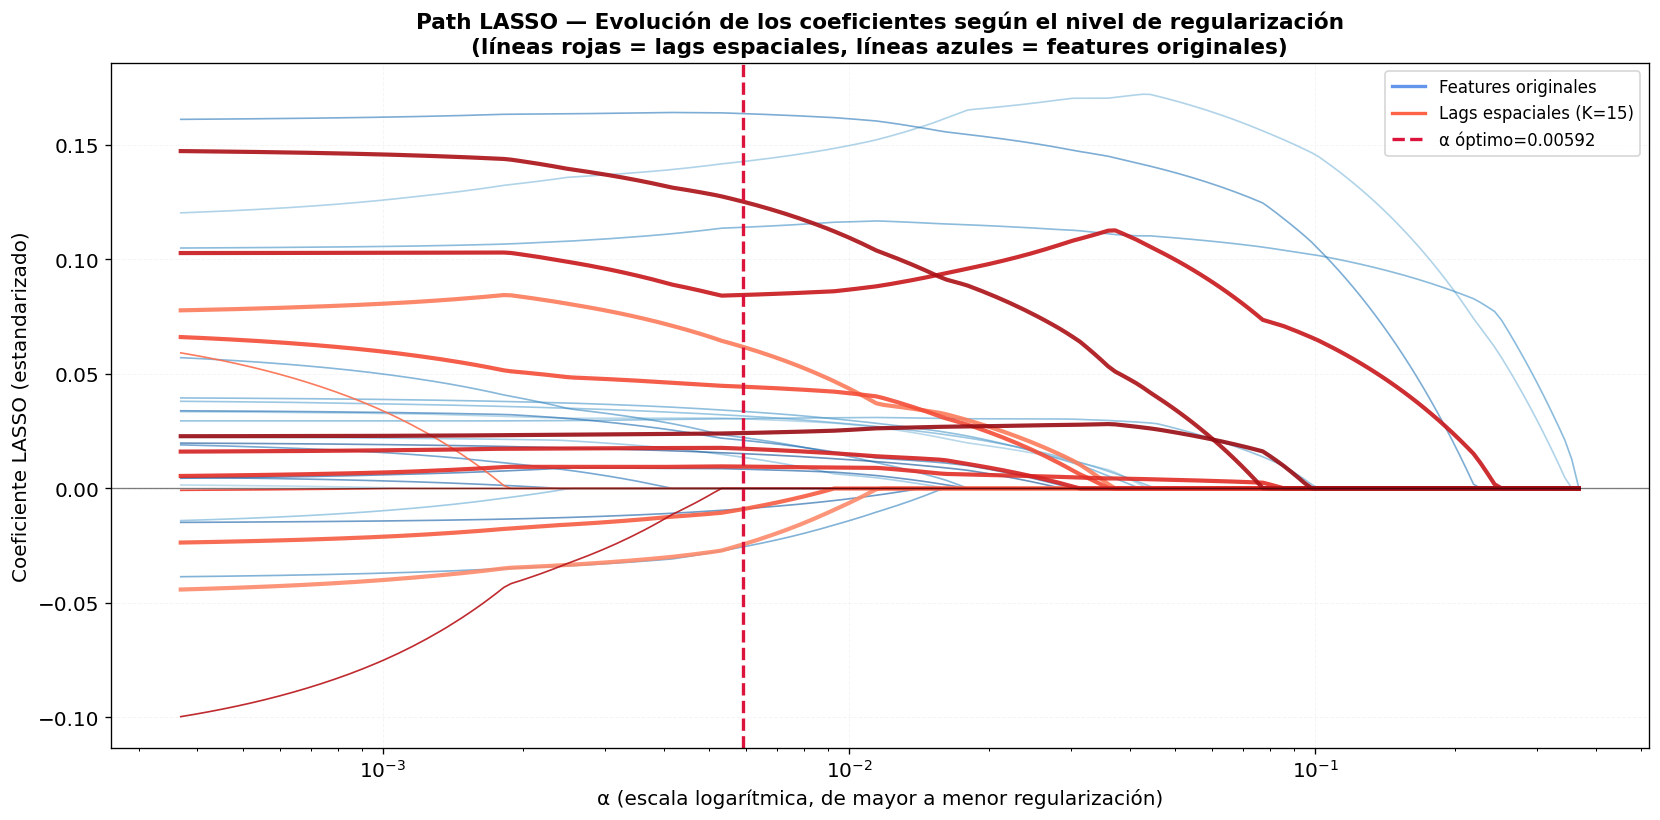

In [8]:
# Figura 2: Path LASSO — cómo evolucionan los coeficientes al variar alpha
# Muestra en qué punto de regularización cada variable "entra" al modelo
alphas_path, coefs_path, _ = lasso_path(X_train_scaled, y_train, n_alphas=200)

fig, ax = plt.subplots(figsize=(14, 7))

lag_features  = [f for f in feature_names if f.startswith('lag_')]
orig_features = [f for f in feature_names if not f.startswith('lag_')]

colors_lag  = plt.cm.Reds(np.linspace(0.4, 0.9, len(lag_features)))
colors_orig = plt.cm.Blues(np.linspace(0.4, 0.9, len(orig_features)))

for i, fname in enumerate(orig_features):
    idx = feature_names.index(fname)
    ax.semilogx(alphas_path, coefs_path[idx], color=colors_orig[i],
                linewidth=1.0, alpha=0.6, linestyle='-')

for i, fname in enumerate(lag_features):
    idx = feature_names.index(fname)
    coef_selected = coef_opt[idx]
    lw = 2.5 if coef_selected != 0 else 1.0
    ax.semilogx(alphas_path, coefs_path[idx], color=colors_lag[i],
                linewidth=lw, alpha=0.9, linestyle='-',
                label=fname.replace('lag_', '').replace('_k15', ''))

ax.axvline(alpha_opt, color='crimson', linestyle='--', linewidth=2,
           label=f'α óptimo = {alpha_opt:.5f}')
ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='cornflowerblue', linewidth=2, label='Features originales'),
    Line2D([0], [0], color='tomato',         linewidth=2, label='Lags espaciales (K=15)'),
    Line2D([0], [0], color='crimson', linestyle='--', linewidth=2, label=f'α óptimo={alpha_opt:.5f}'),
]
ax.legend(handles=legend_elements, fontsize=10, loc='upper right')
ax.set_xlabel('α (escala logarítmica, de mayor a menor regularización)', fontsize=12)
ax.set_ylabel('Coeficiente LASSO (estandarizado)', fontsize=12)
ax.set_title('Path LASSO — Evolución de los coeficientes según el nivel de regularización\n'
             '(líneas rojas = lags espaciales, líneas azules = features originales)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES + '03b_lasso_path.png')
plt.show()

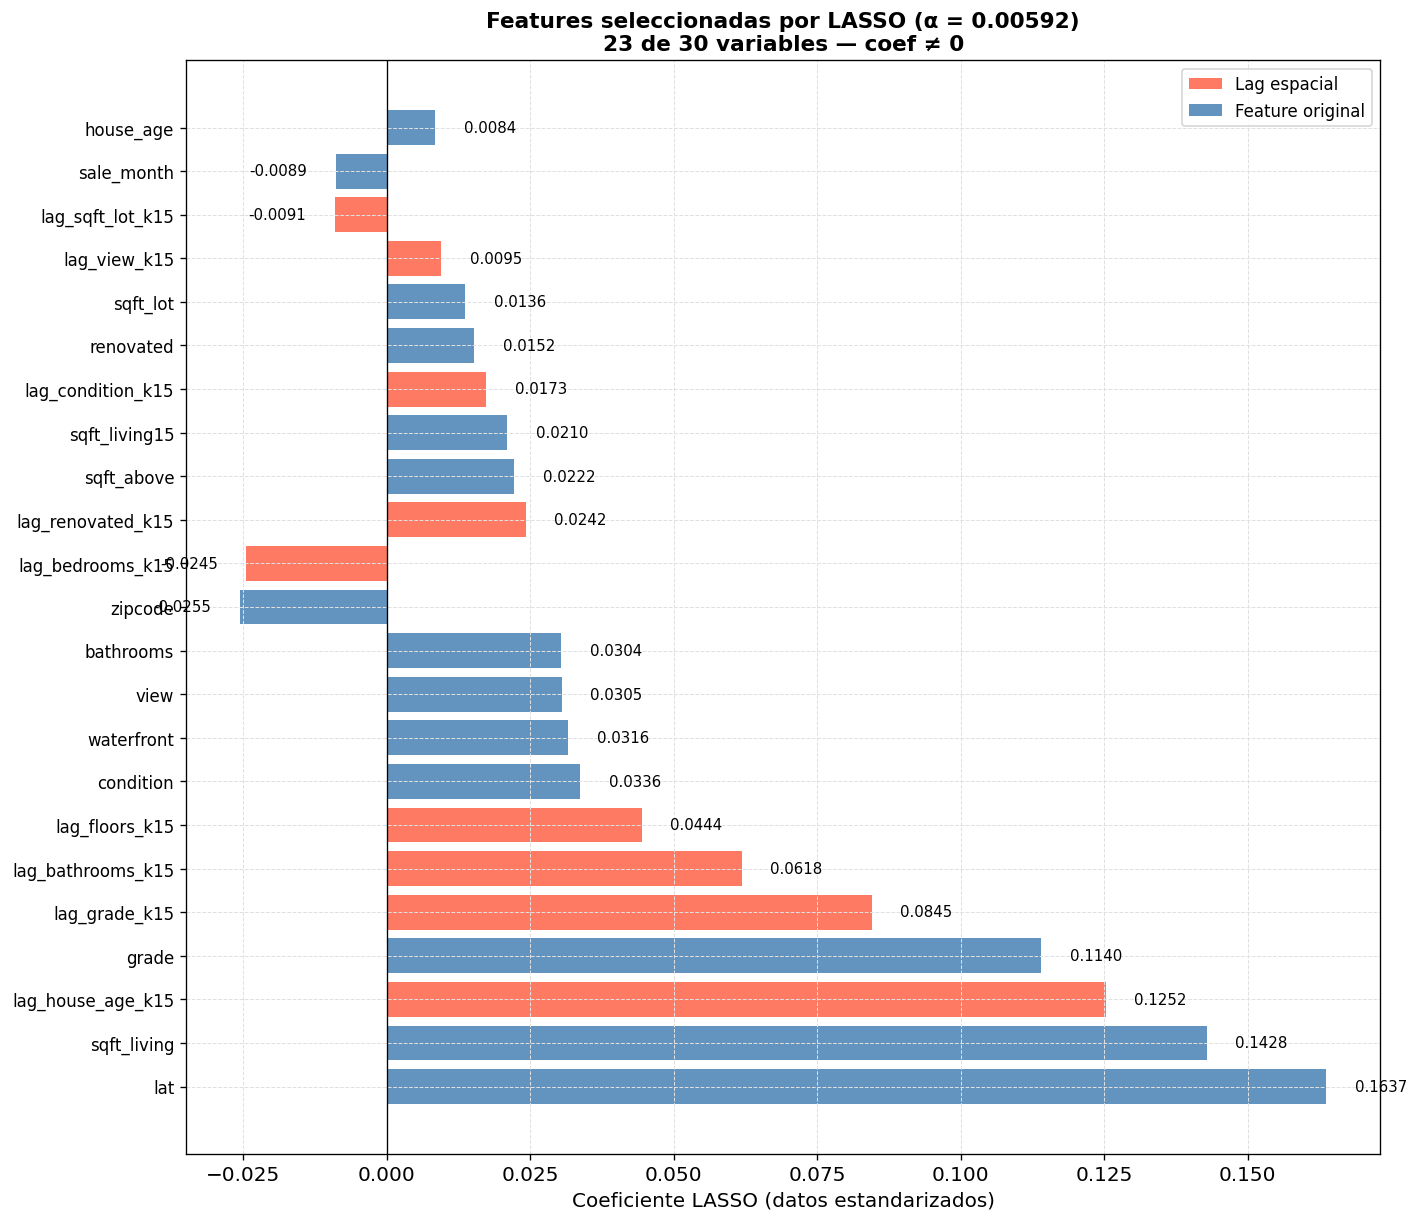

In [9]:
# Figura 3: Coeficientes LASSO en el alpha óptimo — solo features seleccionadas
selected_features = [f for f, c in zip(feature_names, coef_opt) if c != 0]
selected_coefs    = [c for c in coef_opt if c != 0]
colors = ['tomato' if f.startswith('lag_') else 'steelblue' for f in selected_features]

sorted_idx  = np.argsort(np.abs(selected_coefs))[::-1]
sorted_feat = [selected_features[i] for i in sorted_idx]
sorted_coef = [selected_coefs[i] for i in sorted_idx]
sorted_col  = [colors[i] for i in sorted_idx]

fig, ax = plt.subplots(figsize=(12, max(5, len(sorted_feat) * 0.45)))
bars = ax.barh(range(len(sorted_feat)), sorted_coef, color=sorted_col, alpha=0.85)
ax.set_yticks(range(len(sorted_feat)))
ax.set_yticklabels(sorted_feat, fontsize=10)
ax.axvline(0, color='black', linewidth=0.8)

for i, (bar, val) in enumerate(zip(bars, sorted_coef)):
    ax.text(val + (0.005 if val >= 0 else -0.005), i, f'{val:.4f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='tomato',    alpha=0.85, label='Lag espacial'),
    Patch(facecolor='steelblue', alpha=0.85, label='Feature original'),
]
ax.legend(handles=legend_elements, fontsize=10)
ax.set_xlabel('Coeficiente LASSO (datos estandarizados)', fontsize=12)
ax.set_title(f'Features seleccionadas por LASSO (α = {alpha_opt:.5f})\n'
             f'{len(sorted_feat)} de {n_total} variables — coef ≠ 0',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES + '03b_lasso_coeficientes.png', bbox_inches='tight')
plt.show()

## 5. Construcción de los datasets de salida

Los datasets de salida (`X_train_lasso.csv`, `X_test_lasso.csv`) contienen **únicamente las features seleccionadas por LASSO**, en sus **valores originales sin estandarizar**. Esto es importante porque:

- El modelo **SLX** (OLS) no requiere estandarización y sus coeficientes serán interpretables como semi-elasticidades
- Los modelos **RF y XGBoost** son invariantes a la escala y tampoco la necesitan

In [10]:
# Features seleccionadas por LASSO (coef != 0), en escala original
selected_features = [f for f, c in zip(feature_names, coef_opt) if c != 0]
selected_coefs    = {f: float(c) for f, c in zip(feature_names, coef_opt) if c != 0}

print(f'Features seleccionadas por LASSO ({len(selected_features)} de {n_total}):')
lags_selected = [f for f in selected_features if f.startswith('lag_')]
orig_selected = [f for f in selected_features if not f.startswith('lag_')]
print(f'  - Originales seleccionadas:    {len(orig_selected)}')
for f in orig_selected:
    print(f'      {f}  (coef={selected_coefs[f]:.5f})')
print(f'  - Lags espaciales seleccionados: {len(lags_selected)}')
for f in lags_selected:
    print(f'      {f}  (coef={selected_coefs[f]:.5f})')

# Dataset con features seleccionadas (en escala original) — válido para ML y SLX
X_train_lasso = X_train[selected_features].copy()
X_test_lasso  = X_test[selected_features].copy()

# Para SLX usamos el mismo dataset (ya no existe lag_log_price que excluir)
X_train_slx = X_train_lasso.copy()
X_test_slx  = X_test_lasso.copy()

print(f'\nDataset LASSO / SLX: {X_train_lasso.shape[1]} features (mismo para ML y SLX)')


Features seleccionadas por LASSO (23 de 30):
  - Originales seleccionadas:    14
      bathrooms  (coef=0.03037)
      sqft_living  (coef=0.14284)
      sqft_lot  (coef=0.01362)
      waterfront  (coef=0.03165)
      view  (coef=0.03048)
      condition  (coef=0.03364)
      grade  (coef=0.11402)
      sqft_above  (coef=0.02216)
      zipcode  (coef=-0.02555)
      lat  (coef=0.16367)
      sqft_living15  (coef=0.02101)
      sale_month  (coef=-0.00893)
      house_age  (coef=0.00839)
      renovated  (coef=0.01518)
  - Lags espaciales seleccionados: 9
      lag_bedrooms_k15  (coef=-0.02448)
      lag_bathrooms_k15  (coef=0.06180)
      lag_sqft_lot_k15  (coef=-0.00907)
      lag_floors_k15  (coef=0.04442)
      lag_view_k15  (coef=0.00952)
      lag_condition_k15  (coef=0.01735)
      lag_grade_k15  (coef=0.08450)
      lag_house_age_k15  (coef=0.12524)
      lag_renovated_k15  (coef=0.02417)

Dataset LASSO / SLX: 23 features (mismo para ML y SLX)


In [11]:
# Guardar datasets
X_train_lasso.to_csv(PROCESSED + 'X_train_lasso.csv', index=False)
X_test_lasso.to_csv(PROCESSED + 'X_test_lasso.csv',   index=False)
X_train_slx.to_csv(PROCESSED + 'X_train_slx.csv',     index=False)
X_test_slx.to_csv(PROCESSED + 'X_test_slx.csv',       index=False)

# Guardar lista de features seleccionadas con sus coeficientes
lasso_output = {
    'alpha_optimo':             alpha_opt,
    'n_features_entrada':       n_total,
    'n_features_seleccionadas': len(selected_features),
    'features_seleccionadas':   selected_features,
    'features_slx':             selected_features,  # idéntico: no hay lag_log_price que excluir
    'coeficientes':             selected_coefs,
    'features_eliminadas':      [f for f in feature_names if f not in selected_features],
}

with open(METRICS + 'lasso_selected_features.json', 'w', encoding='utf-8') as f_out:
    json.dump(lasso_output, f_out, indent=2, ensure_ascii=False)

print('Archivos guardados:')
print(f'  ✓  data/processed/X_train_lasso.csv  ({X_train_lasso.shape[0]} x {X_train_lasso.shape[1]})')
print(f'  ✓  data/processed/X_test_lasso.csv   ({X_test_lasso.shape[0]} x {X_test_lasso.shape[1]})')
print(f'  ✓  data/processed/X_train_slx.csv    ({X_train_slx.shape[0]} x {X_train_slx.shape[1]})')
print(f'  ✓  data/processed/X_test_slx.csv     ({X_test_slx.shape[0]} x {X_test_slx.shape[1]})')
print(f'  ✓  outputs/metrics/lasso_selected_features.json')
print(f'  ✓  outputs/models/lasso_scaler.joblib')


Archivos guardados:
  ✓  data/processed/X_train_lasso.csv  (17289 x 23)
  ✓  data/processed/X_test_lasso.csv   (4323 x 23)
  ✓  data/processed/X_train_slx.csv    (17289 x 23)
  ✓  data/processed/X_test_slx.csv     (4323 x 23)
  ✓  outputs/metrics/lasso_selected_features.json
  ✓  outputs/models/lasso_scaler.joblib


## 6. Tabla resumen final

In [12]:
# Tabla resumen de todas las features: seleccionada / eliminada, coeficiente, correlación
corr_with_target = {f: X_train[f].corr(y_train) for f in feature_names}

summary_rows = []
for feat, coef in zip(feature_names, coef_opt):
    summary_rows.append({
        'Feature':          feat,
        'Tipo':             'Lag espacial' if feat.startswith('lag_') else 'Original',
        'Corr. log_price':  round(corr_with_target[feat], 4),
        'Coef. LASSO':      round(coef, 6),
        'Seleccionada':     '✓ SÍ' if coef != 0 else '✗ NO',
    })

summary_df = pd.DataFrame(summary_rows).sort_values('Coef. LASSO', ascending=False, key=abs)

print('Resumen de selección de variables LASSO:')
display(summary_df.to_string(index=False))
print(f'\nResumen estadístico:')
print(f'  α óptimo:                    {alpha_opt:.6f}')
print(f'  Features entrada:            {n_total}')
print(f'  Features seleccionadas:      {len(selected_features)}')
print(f'  Features eliminadas:         {n_total - len(selected_features)}')
print(f'  R² LASSO (train, escalado):  {lasso_cv.score(X_train_scaled, y_train):.4f}')


Resumen de selección de variables LASSO:


'            Feature         Tipo  Corr. log_price  Coef. LASSO Seleccionada\n                lat     Original           0.4517     0.163674         ✓ SÍ\n        sqft_living     Original           0.6944     0.142843         ✓ SÍ\n  lag_house_age_k15 Lag espacial           0.0377     0.125238         ✓ SÍ\n              grade     Original           0.7019     0.114020         ✓ SÍ\n      lag_grade_k15 Lag espacial           0.6254     0.084497         ✓ SÍ\n  lag_bathrooms_k15 Lag espacial           0.4946     0.061800         ✓ SÍ\n     lag_floors_k15 Lag espacial           0.2806     0.044420         ✓ SÍ\n          condition     Original           0.0407     0.033636         ✓ SÍ\n         waterfront     Original           0.1652     0.031648         ✓ SÍ\n               view     Original           0.3406     0.030478         ✓ SÍ\n          bathrooms     Original           0.5525     0.030367         ✓ SÍ\n            zipcode     Original          -0.0389    -0.025547         ✓ SÍ


Resumen estadístico:
  α óptimo:                    0.005918
  Features entrada:            30
  Features seleccionadas:      23
  Features eliminadas:         7
  R² LASSO (train, escalado):  0.8271


## 7. Conclusiones y próximos pasos

### ¿Qué hemos conseguido?

En este notebook hemos aplicado el proceso de **regularización LASSO** para identificar el subconjunto de variables que aportan información predictiva real sobre el precio de la vivienda en King County, resolviendo el problema de multicolinealidad que surge al combinar las 18 features originales con los 12 lags espaciales.

El alpha óptimo seleccionado por `LassoCV` (5-fold cross-validation) elimina las variables redundantes, garantizando que:
1. El modelo SLX (OLS) podrá estimar coeficientes estables e interpretables
2. Los efectos directos (β) y los efectos de spillover (θ) estarán bien identificados
3. Los tests de significatividad estadística serán fiables

### Datasets generados y sus usos

| Dataset | Dimensiones | Uso |
|---|---|---|
| `X_train_lasso.csv` | 17.289 × {selected} | Referencia: todas las features seleccionadas |
| `X_test_lasso.csv`  | 4.323 × {selected}  | Referencia: todas las features seleccionadas |
| `X_train_slx.csv`   | 17.289 × {selected} | **→ Notebook SLX** (mismo que lasso) |
| `X_test_slx.csv`    | 4.323 × {selected}  | **→ Notebook SLX** (mismo que lasso) |

### Próximos pasos

- **`04_random_forest.ipynb`** — Usa `X_train_spatial.csv` (30 features), sin LASSO (RF tolera multicolinealidad)
- **`05_xgboost.ipynb`** — XGBoost con `X_train_spatial.csv` (30 features)
- **Notebook SLX** — Modelo hedónico SLX con `X_train_slx.csv` (features LASSO)
- **`07_comparativa_final.ipynb`** — Comparativa de los tres modelos con RMSE, MAE, R², Moran's I residuos